# 02. ATTR type silver + EDA

Задача: собрать **качественный silver** для типизации ATTR-span  
(`memory_storage`, `size`, `color`, …) — **без** локальных словарей и самодельных brand/model regex.

Учитель = тот же пайплайн, что NER:

```text
query → WeakLabeler.label_query → BIO
      → bio_to_entities → ATTR spans
      → _guess_attr_type (ATTR_PATTERNS + COLORS)
```

## Несколько ATTR в одном запросе

`ноутбук asus 16 гб 15.6 дюйм` → **две** строки silver:

| span_text | y |
|---|---|
| `16 гб` | memory_storage |
| `15.6 дюйм` | size |

Для будущего clf: n-grams **только по `span_text`**; чужие ATTR в контексте **маскируем**, не склеиваем.

Обучение классификаторов — **отдельный** ноутбук (после того как датасет устраивает).


## 0. Setup

In [1]:
%matplotlib inline
import sys
import json
import re
import warnings
from pathlib import Path
from collections import Counter

ROOT = Path.cwd().resolve()
if ROOT.name in {"markov_typer", "notebooks"}:
    ROOT = ROOT.parents[1] if ROOT.name == "markov_typer" else ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data_utils import (
    apply_plot_style, ensure_dirs, load_query_clicks,
    ARTIFACTS_DIR, FIGURES_DIR, MVIDEO_RED, DARK_SLATE, MUTED, save_stats,
)
from src.ner.labeling import (
    WeakLabeler,
    bio_to_entities,
    entities_to_structured,
    _guess_attr_type,
    ATTR_PATTERNS,
)
from src.preprocessing.pipeline import basic_clean, _norm_key

warnings.filterwarnings("ignore", category=FutureWarning)
ensure_dirs()
apply_plot_style()

OUT = ROOT / "artifacts" / "attr_type"
OUT.mkdir(parents=True, exist_ok=True)
FIG = FIGURES_DIR / "attr_type"
FIG.mkdir(parents=True, exist_ok=True)
print("OUT", OUT)
print("ATTR types in labeling:", [n for _, n in ATTR_PATTERNS])


d:\Projects-26-06-2026\mvideo-ner-search\.venv\Lib\site-packages\pymorphy2\analyzer.py:114: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


OUT D:\Projects-26-06-2026\mvideo-ner-search\artifacts\attr_type
ATTR types in labeling: ['memory_storage', 'dimensions', 'size', 'power', 'current', 'area', 'weight', 'volume', 'frequency', 'noise_level', 'magnification', 'flow_rate', 'resolution_standard', 'resolution_exact', 'ip_rating', 'connectivity', 'time', 'temperature', 'voltage', 'quantity', 'age_restriction', 'pages_yield', 'warranty_period', 'impedance', 'rpm', 'megapixels', 'airflow_capacity', 'density']


## 1. Конфиг

| параметр | смысл |
|---|---|
| `SAMPLE_N` / `MAX_QUERIES` | сэмпл кликов → unique queries |
| `MIN_SPAN_LEN` | дроп пустых/крошечных span |
| unit-aug | доп. строки `гб↔gb↔…` с `is_aug=True` |


In [2]:
SAMPLE_N = 120_000
MAX_QUERIES = 40_000
SEED = 42
MIN_SPAN_LEN = 1
RARE_SUPPORT = 25  # только для отчёта EDA, в датасет не схлопываем

UNIT_AUG = {
    "гб": ["gb", "кб", "kb"],
    "gb": ["гб", "кб", "kb"],
    "тб": ["tb"],
    "tb": ["тб"],
    "мб": ["mb"],
    "mb": ["мб"],
    "вт": ["w"],
    "w": ["вт"],
    "кг": ["kg"],
    "kg": ["кг"],
}


## 2. WeakLabeler — единственный источник сущностей

Словари: `artifacts/brands.txt`, `categories.txt`, `model_phrases.txt`.  
`BRAND` / `MODEL` / `CATEGORY` / `ATTR` уже разведены внутри `label_query` — **не** копируем find_brand / looks_like_model сюда.


In [3]:
labeler = WeakLabeler.from_files(
    ARTIFACTS_DIR / "brands.txt",
    ARTIFACTS_DIR / "categories.txt",
    models_path=ARTIFACTS_DIR / "model_phrases.txt",
)
print(
    f"brands={len(labeler.brands)} cats={len(labeler.categories)} "
    f"models={len(labeler.models)} colors={len(labeler.colors)}"
)

# sanity: типы из labeling.py
for demo in ["16 гб", "15.6 дюйм", "белый", "1920x1080", "xyz"]:
    print(f"  {_guess_attr_type(demo)!r:20} <- {demo!r}")


brands=1609 cats=1431 models=6130 colors=92
  'memory_storage'     <- '16 гб'
  'size'               <- '15.6 дюйм'
  'color'              <- 'белый'
  'dimensions'         <- '1920x1080'
  'other'              <- 'xyz'


## 3. Схема silver-строки и маскирование

Одна строка = **один** ATTR-span.

| колонка | смысл |
|---|---|
| `query`, `query_norm` | исходник / текст для labeler |
| `span_text`, `span_start`, `span_end` | текст и char-span ATTR |
| `y` | `_guess_attr_type` → `memory_storage` / `color` / `other` / … |
| `brand`, `category`, `model` | из `entities_to_structured` |
| `n_attrs_in_query` | сколько ATTR в запросе |
| `bio_tags` | BIO-строка для аудита |
| `query_masked_all_attr` | **все** ATTR → `<ATTR>` |
| `query_keep_span_mask_others` | текущий span текстом, остальные ATTR → `<ATTR>` |
| `query_masked_entities` | BRAND/CAT/MODEL/ATTR → плейсхолдеры |
| `is_aug` | unit-aug строка или нет |

**Политика:** n-grams типа — только `span_text`; чужие ATTR из контекста **исключаем** маской, не склеиваем.


In [4]:
_MULTI_SPACE = re.compile(r"\s+")
_ENT_TOKEN = {
    "BRAND": "<BRAND>",
    "CATEGORY": "<CAT>",
    "MODEL": "<MODEL>",
    "ATTR": "<ATTR>",
    "GENRE": "<GENRE>",
    "PERSON": "<PERSON>",
}


def _mask_spans(text: str, spans: list[tuple[int, int, str]]) -> str:
    """spans: (start, end, replacement), applied right-to-left."""
    chars = list(text)
    for a, b, repl in sorted(spans, key=lambda x: -x[0]):
        chars[a:b] = list(repl)
    return _MULTI_SPACE.sub(" ", "".join(chars)).strip()


def mask_all_attr(text: str, attr_ents: list[dict]) -> str:
    spans = [(e["span"][0], e["span"][1], "<ATTR>") for e in attr_ents if "span" in e]
    return _mask_spans(text, spans)


def mask_keep_span(text: str, attr_ents: list[dict], keep: dict) -> str:
    spans = []
    for e in attr_ents:
        if "span" not in e:
            continue
        a, b = e["span"]
        if e is keep or (a == keep.get("span", [None])[0] and b == keep.get("span", [None, None])[1]):
            continue
        spans.append((a, b, "<ATTR>"))
    return _mask_spans(text, spans)


def mask_all_entities(text: str, ents: list[dict]) -> str:
    spans = []
    for e in ents:
        if "span" not in e:
            continue
        repl = _ENT_TOKEN.get(e["label"], f"<{e['label']}>")
        spans.append((e["span"][0], e["span"][1], repl))
    return _mask_spans(text, spans)


def aug_span_text(span_text: str, y: str) -> list[tuple[str, bool]]:
    """[(text, is_aug), ...] — оригинал + unit synonyms."""
    out = [(span_text, False)]
    if y in {"other", "color"}:
        return out
    parts = span_text.split()
    if len(parts) < 2:
        return out
    last = parts[-1].lower()
    for alt in UNIT_AUG.get(last, []):
        out.append((" ".join(parts[:-1] + [alt]), True))
    return out


def build_rows_for_query(query: str, labeler: WeakLabeler) -> list[dict]:
    q_clean = basic_clean(query, lowercase=False)
    q_norm = _norm_key(q_clean)
    if len(q_norm) < 2:
        return []
    tags = labeler.label_query(q_norm)
    ents = bio_to_entities(tags, query=q_norm)
    struct = entities_to_structured(ents, labeler)
    attr_ents = [e for e in ents if e["label"] == "ATTR" and (e.get("text") or "").strip()]
    if not attr_ents:
        return []
    bio_str = " ".join(f"{t}/{g}" for t, g in tags)
    masked_all = mask_all_attr(q_norm, attr_ents)
    masked_ent = mask_all_entities(q_norm, ents)
    brand = struct.get("brand") or ""
    category = struct.get("category") or ""
    model = struct.get("model") or ""
    rows = []
    for e in attr_ents:
        st0 = (e.get("text") or "").strip()
        if len(st0) < MIN_SPAN_LEN:
            continue
        span = e.get("span") or [None, None]
        y = _guess_attr_type(st0)
        keep_masked = mask_keep_span(q_norm, attr_ents, e)
        for st, is_aug in aug_span_text(st0, y):
            rows.append({
                "query": query,
                "query_norm": q_norm,
                "span_text": st,
                "span_start": span[0],
                "span_end": span[1],
                "y": y,
                "brand": brand,
                "category": category,
                "model": model,
                "n_attrs_in_query": len(attr_ents),
                "bio_tags": bio_str,
                "query_masked_all_attr": masked_all,
                "query_keep_span_mask_others": keep_masked,
                "query_masked_entities": masked_ent,
                "is_aug": is_aug,
            })
    return rows


# demo multi-ATTR + MODEL (+ glued unit caveats)
for q in [
    "ноутбук asus 16 гб 15.6 дюйм",
    "asus tuf gaming a15 16 гб",
    "asus tuf gaming a15 16gb",  # glued: model_phrases may swallow units
]:
    demo = pd.DataFrame(build_rows_for_query(q, labeler))
    print("\nQ:", q)
    tags = labeler.label_query(_norm_key(basic_clean(q, lowercase=False)))
    print("  BIO:", tags)
    if demo.empty:
        print("  (no ATTR rows)")
    else:
        display(demo.loc[~demo["is_aug"], [
            "span_text", "y", "brand", "category", "model",
            "query_keep_span_mask_others", "query_masked_all_attr",
        ]])



Q: ноутбук asus 16 гб 15.6 дюйм
  BIO: [('ноутбук', 'B-CATEGORY'), ('asus', 'B-BRAND'), ('16', 'B-ATTR'), ('гб', 'I-ATTR'), ('15.6', 'B-ATTR'), ('дюйм', 'I-ATTR')]


,span_text,y,brand,category,model,query_keep_span_mask_others,query_masked_all_attr
0,16 гб,memory_storage,ASUS,ноутбук,,ноутбук asus 16 гб <ATTR>,ноутбук asus <ATTR> <ATTR>
4,15.6 дюйм,size,ASUS,ноутбук,,ноутбук asus <ATTR> 15.6 дюйм,ноутбук asus <ATTR> <ATTR>



Q: asus tuf gaming a15 16 гб
  BIO: [('asus', 'B-BRAND'), ('tuf', 'B-MODEL'), ('gaming', 'I-MODEL'), ('a15', 'I-MODEL'), ('16', 'B-ATTR'), ('гб', 'I-ATTR')]


,span_text,y,brand,category,model,query_keep_span_mask_others,query_masked_all_attr
0,16 гб,memory_storage,ASUS,,tuf gaming a15,asus tuf gaming a15 16 гб,asus tuf gaming a15 <ATTR>



Q: asus tuf gaming a15 16gb
  BIO: [('asus', 'B-BRAND'), ('tuf', 'B-MODEL'), ('gaming', 'I-MODEL'), ('a15', 'I-MODEL'), ('16', 'B-MODEL'), ('gb', 'I-MODEL')]
  (no ATTR rows)


## 4. Сбор silver по кликам

In [5]:
clicks = load_query_clicks(n=SAMPLE_N, seed=SEED, random=True, columns=["query_text"])
queries = (
    clicks["query_text"].fillna("").astype(str).str.strip()
    .loc[lambda s: s.str.len().between(2, 120)]
    .drop_duplicates()
    .head(MAX_QUERIES)
    .tolist()
)
print(f"unique queries: {len(queries):,}")

rows: list[dict] = []
n_with_attr = 0
n_multi = 0
for q in queries:
    r = build_rows_for_query(q, labeler)
    if not r:
        continue
    n_with_attr += 1
    if r[0]["n_attrs_in_query"] >= 2:
        n_multi += 1
    rows.extend(r)

silver = pd.DataFrame(rows)
print(f"queries with ATTR: {n_with_attr:,}  multi-ATTR queries: {n_multi:,} ({n_multi/max(n_with_attr,1):.1%})")
print(f"silver rows (with aug): {len(silver):,}  raw: {(~silver['is_aug']).sum():,}  aug: {silver['is_aug'].sum():,}")
print("\ny value_counts (raw only):")
print(silver.loc[~silver["is_aug"], "y"].value_counts())
display(silver.head(6))


unique queries: 38,102
queries with ATTR: 3,207  multi-ATTR queries: 381 (11.9%)
silver rows (with aug): 5,149  raw: 3,696  aug: 1,453

y value_counts (raw only):
y
color                  1002
size                    662
memory_storage          438
weight                  289
connectivity            274
volume                  247
other                   193
power                   159
dimensions              122
frequency                70
voltage                  62
resolution_standard      49
current                  40
time                     29
warranty_period          22
area                     18
quantity                 10
temperature               4
noise_level               3
impedance                 2
megapixels                1
Name: count, dtype: int64


,query,query_norm,span_text,span_start,span_end,y,brand,category,model,n_attrs_in_query,bio_tags,query_masked_all_attr,query_keep_span_mask_others,query_masked_entities,is_aug
0,встраиваемые посудомоечные машины 45см,встраиваемые посудомоечные машины 45 см,45 см,34,39,size,,посудомоечная машина,,1,встраиваемые/O посудомоечные/B-CATEGORY машины...,встраиваемые посудомоечные машины <ATTR>,встраиваемые посудомоечные машины 45 см,встраиваемые <CAT> <ATTR>,False
1,Посудомоечные машины 45 см,посудомоечные машины 45 см,45 см,21,26,size,,посудомоечная машина,,1,посудомоечные/B-CATEGORY машины/I-CATEGORY 45/...,посудомоечные машины <ATTR>,посудомоечные машины 45 см,<CAT> <ATTR>,False
2,"Варочная панель PKE611BB2E, чёрная",варочная панель pke611bb2 e черная,черная,28,34,color,,варочная панель,,1,варочная/B-CATEGORY панель/I-CATEGORY pke611bb...,варочная панель pke611bb2 e <ATTR>,варочная панель pke611bb2 e черная,<CAT> pke611bb2 e <ATTR>,False
3,Iphone 15 розовый состояние новый с ру стор,iphone 15 розовый состояние новый с ру стор,розовый,10,17,color,Apple,,,1,iphone/B-BRAND 15/O розовый/B-ATTR состояние/O...,iphone 15 <ATTR> состояние новый с ру стор,iphone 15 розовый состояние новый с ру стор,<BRAND> 15 <ATTR> состояние новый с ру стор,False
4,телевизоры 40 дюйм samsung,телевизоры 40 дюйм samsung,40 дюйм,11,18,size,Samsung,телевизоры,,1,телевизоры/B-CATEGORY 40/B-ATTR дюйм/I-ATTR sa...,телевизоры <ATTR> samsung,телевизоры 40 дюйм samsung,<CAT> <ATTR> <BRAND>,False
5,адаптер wifi,адаптер wifi,wifi,8,12,connectivity,,,,1,адаптер/O wifi/B-ATTR,адаптер <ATTR>,адаптер wifi,адаптер <ATTR>,False


## 5. EDA

Смотрим покрытие типов, multi-ATTR, контекст brand/cat/model, дыры (`other`), путаницу `dimensions` ↔ `resolution_exact`.


,metric,value
0,queries_sampled,38102.0000
1,queries_with_ATTR,3207.0000
2,multi_ATTR_queries,381.0000
3,multi_ATTR_share,0.1188
4,silver_rows_raw,3696.0000
5,silver_rows_aug,1453.0000
6,n_types,21.0000
7,share_with_brand,0.5547
8,share_with_category,0.7662
9,share_with_model,0.2700


rare types (support < 25) — leave in dataset, flag for train later:


,support
y,
warranty_period,22
area,18
quantity,10
temperature,4
noise_level,3
impedance,2
megapixels,1


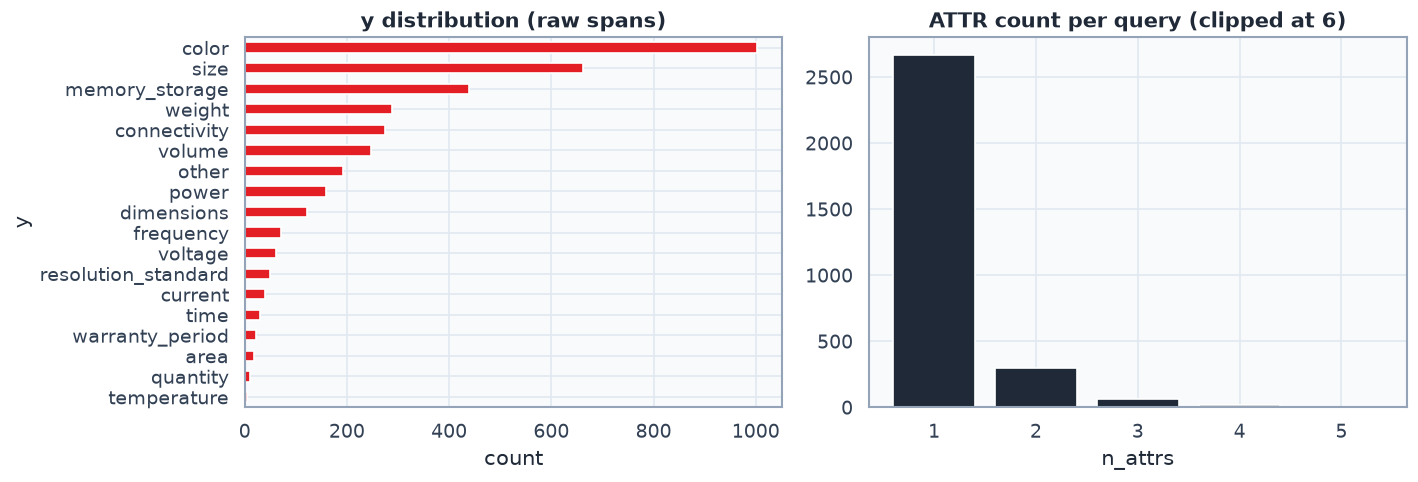

In [6]:
raw = silver.loc[~silver["is_aug"]].copy()

# --- overview ---
overview = pd.DataFrame([
    {"metric": "queries_sampled", "value": len(queries)},
    {"metric": "queries_with_ATTR", "value": n_with_attr},
    {"metric": "multi_ATTR_queries", "value": n_multi},
    {"metric": "multi_ATTR_share", "value": round(n_multi / max(n_with_attr, 1), 4)},
    {"metric": "silver_rows_raw", "value": int((~silver["is_aug"]).sum())},
    {"metric": "silver_rows_aug", "value": int(silver["is_aug"].sum())},
    {"metric": "n_types", "value": int(raw["y"].nunique())},
    {"metric": "share_with_brand", "value": round((raw["brand"].astype(str).str.len() > 0).mean(), 4)},
    {"metric": "share_with_category", "value": round((raw["category"].astype(str).str.len() > 0).mean(), 4)},
    {"metric": "share_with_model", "value": round((raw["model"].astype(str).str.len() > 0).mean(), 4)},
    {"metric": "share_y_other", "value": round((raw["y"] == "other").mean(), 4)},
    {"metric": "share_y_color", "value": round((raw["y"] == "color").mean(), 4)},
])
display(overview)

vc = raw["y"].value_counts()
rare = vc[vc < RARE_SUPPORT]
print(f"rare types (support < {RARE_SUPPORT}) — leave in dataset, flag for train later:")
display(rare.to_frame("support") if len(rare) else pd.DataFrame({"support": []}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
vc.head(18).iloc[::-1].plot.barh(ax=axes[0], color=MVIDEO_RED)
axes[0].set_title("y distribution (raw spans)")
axes[0].set_xlabel("count")

n_attr_hist = raw.drop_duplicates("query_norm")["n_attrs_in_query"].clip(upper=6).value_counts().sort_index()
axes[1].bar(n_attr_hist.index.astype(str), n_attr_hist.values, color=DARK_SLATE)
axes[1].set_title("ATTR count per query (clipped at 6)")
axes[1].set_xlabel("n_attrs")
fig.tight_layout()
fig.savefig(FIG / "01_y_and_multi.png", dpi=120, bbox_inches="tight")
plt.show()


In [7]:
# multi-ATTR examples
multi = raw[raw["n_attrs_in_query"] >= 2]
print(f"multi-ATTR rows: {len(multi):,}")
# one query → list of (span, y)
ex_q = (
    multi.groupby("query_norm")
    .agg(spans=("span_text", list), types=("y", list), brand=("brand", "first"), n=("n_attrs_in_query", "first"))
    .reset_index()
    .head(12)
)
display(ex_q)

# top span texts per frequent type
for typ in vc.head(6).index:
    top = raw.loc[raw["y"] == typ, "span_text"].value_counts().head(8)
    print(f"\n=== {typ} ===")
    print(top.to_string())


multi-ATTR rows: 870


,query_norm,spans,types,brand,n
0,10.9 планшет samsung galaxy tab s10 lite 5 g 1...,"[5 g, 128 гб, серый]","[weight, memory_storage, color]",Samsung,3
1,10.9 планшет samsung galaxy tab s10 красныйlit...,"[wi fi, 128 гб, красный]","[connectivity, memory_storage, color]",Samsung,3
2,1000 гб m.2 nvme накопитель adata legend 960 m...,"[1000 гб, aleg-960 m-1]","[memory_storage, size]",ADATA,2
3,1000 гб m.2 nvme накопитель wd black sn7100 wd...,"[1000 гб, black]","[memory_storage, color]",,2
4,11 планшет apple ipad 11 th gen wi fi 256 гб р...,"[wi fi, 256 гб, розовый]","[connectivity, memory_storage, color]",Apple,3
5,11 планшет huawei matepad se 11 lte 128 гб серый,"[128 гб, серый]","[memory_storage, color]",HUAWEI,2
6,11 планшет huawei matepad se 11 lte 8 128 гб с...,"[128 гб, серый]","[memory_storage, color]",HUAWEI,2
7,11 планшет huawei matepad se 11 wi fi 128 гб с...,"[wi fi, 128 гб, серый]","[connectivity, memory_storage, color]",HUAWEI,3
8,11 планшет samsung galaxy tab a9 5 g 128 гб,"[5 g, 128 гб]","[weight, memory_storage]",Samsung,2
9,11.5 планшет huawei matepad 11.5 2025 wi fi 12...,"[wi fi, 128 гб, серый]","[connectivity, memory_storage, color]",HUAWEI,3



=== color ===
span_text
черный         231
белый          200
black           62
серый           61
белая           54
черная          39
серебристый     37
white           26

=== size ===
span_text
60 см        116
45 см         87
50 см         57
28 см         15
55 дюймов     12
70 см          9
55 см          8
46 mm          8

=== memory_storage ===
span_text
256 гб    120
512 гб     72
1 тб       53
128 гб     41
16 гб      22
2 тб       16
8 гб       14
8 gb       13

=== weight ===
span_text
5 g      88
7 кг     38
6 кг     29
8 кг     29
5 кг     24
9 кг     16
10 кг    14
4 кг     10

=== connectivity ===
span_text
wi fi        100
wifi          42
bluetooth     37
hdmi          36
lte           23
gps           12
nfc            6
vga            5

=== volume ===
span_text
50 л         29
30 л         12
5 л          12
100 л         9
6 л           8
3 л           8
15 л          8
50 литров     7


In [8]:
# dimensions vs resolution_exact — confusion-prone
confusable = raw[raw["y"].isin(["dimensions", "resolution_exact"])]
print("dimensions / resolution_exact sample:")
display(confusable[["query_norm", "span_text", "y", "brand", "category"]].head(20))

# y=other — regex holes / leftover ATTR
other = raw[raw["y"] == "other"]
print(f"\nother count: {len(other):,}")
display(other["span_text"].value_counts().head(25).to_frame("count"))
display(other[["query_norm", "span_text", "brand", "category", "model"]].head(15))

# color sample
colors = raw[raw["y"] == "color"]
print(f"\ncolor count: {len(colors):,}")
display(colors["span_text"].value_counts().head(15).to_frame("count"))


dimensions / resolution_exact sample:


,query_norm,span_text,y,brand,category
45,блока питания пк 3х2 х2,3х2 х2,dimensions,,блока питания пк
160,27 монитор asus tuf gaming vg279q5 a 1920x1080...,1920x1080,dimensions,ASUS,мониторы
240,бассейн каркасный 457x122,457x122,dimensions,,бассейн
241,монитор игровой 1920x1080 24,1920x1080,dimensions,,монитор игровой
377,кронштейн vesa 200x100,200x100,dimensions,,кронштейн
586,монитор игровой 2560x1440 240 гц,2560x1440,dimensions,,монитор игровой
615,кровать 120х200,120х200,dimensions,,кровать
682,матрас 120х200,120х200,dimensions,,матрас
688,vesa 200x200,200x200,dimensions,,
732,сушильная машина meferi mdr1016 wh hp comfort ...,50x85x56,dimensions,MEFERI,сушильная машина



other count: 193


,count
span_text,
gb,46
g,37
5,30
гб,18
mm,13
мм,4
w,4
a,4
16,3


,query_norm,span_text,brand,category,model
13,смартфоны samsung самсунг z fold 7 5 g 12 256,5,Samsung,смартфон,g 12 256
36,планшет samsung galaxy tab s10 fe 5 g 256 gb,5,Samsung,планшеты,g 256 gb
75,смартфон poco x8 pro 8 256 gb green,gb,Xiaomi,смартфон,x8 pro 8 256
87,смартфон samsung galaxy a36 5 g 8 256 gb,5,Samsung,смартфон,a36
107,xiaomi watch s4 41 мм,мм,Xiaomi,,watch s4 41
136,ноутбук xiaomi redmibook pro 14 a18 sr 39112 r...,16,Xiaomi,ноутбук,g 512 g
173,xiaomi смартфон xiaomi 15 t 12 256 gb gray,gb,Xiaomi,смартфон,15 t 12 256
220,смартфон xiaomi redmi note 13 pro 5 g белый,g,Xiaomi Redmi,смартфон,note 13 pro 5
238,steam deck oled 1 tb,tb,,,steam deck oled 1
254,смартфон samsung galaxy a26 5 g 8 256 gb,5,Samsung,смартфон,g 8 256 gb



color count: 1,002


,count
span_text,
черный,231
белый,200
black,62
серый,61
белая,54
черная,39
серебристый,37
white,26
silver,26


In [9]:
# masking sanity on multi-ATTR
sample_masks = multi.drop_duplicates("query_norm").head(5)
for _, r in sample_masks.iterrows():
    print("Q:", r["query_norm"])
    sub = raw[raw["query_norm"] == r["query_norm"]][["span_text", "y", "query_keep_span_mask_others"]]
    display(sub)
    print("  all_attr:", r["query_masked_all_attr"])
    print("  entities:", r["query_masked_entities"])
    print()

# unit-aug effect
aug_vs = pd.DataFrame({
    "raw_rows": [(~silver["is_aug"]).sum()],
    "aug_rows": [silver["is_aug"].sum()],
    "types_raw": [raw["y"].nunique()],
    "types_all": [silver["y"].nunique()],
})
display(aug_vs)
print("aug examples:")
display(silver.loc[silver["is_aug"], ["span_text", "y", "query_norm"]].head(12))


Q: микроволновки c ширина 48 см высота 28 см глубина 32 см объем 20 л мощность 900 вт


,span_text,y,query_keep_span_mask_others
14,48 см,size,микроволновки c ширина 48 см высота <ATTR> глу...
15,28 см,size,микроволновки c ширина <ATTR> высота 28 см глу...
16,32 см,size,микроволновки c ширина <ATTR> высота <ATTR> гл...
17,20 л,volume,микроволновки c ширина <ATTR> высота <ATTR> гл...
18,900 вт,power,микроволновки c ширина <ATTR> высота <ATTR> гл...


  all_attr: микроволновки c ширина <ATTR> высота <ATTR> глубина <ATTR> объем <ATTR> мощность <ATTR>
  entities: микроволновки c ширина <ATTR> высота <ATTR> глубина <ATTR> объем <ATTR> мощность <ATTR>

Q: apple смартфон apple iphone 17 sim esim - глобальная версия global 8 256 гб голубой


,span_text,y,query_keep_span_mask_others
30,256 гб,memory_storage,apple смартфон apple iphone 17 sim esim - глоб...
34,голубой,color,apple смартфон apple iphone 17 sim esim - глоб...


  all_attr: apple смартфон apple iphone 17 sim esim - глобальная версия global 8 <ATTR> <ATTR>
  entities: <BRAND> <CAT> <BRAND> <BRAND> 17 sim esim - глобальная версия global 8 <ATTR> <ATTR>

Q: смарт-часы samsung galaxy watch ultra 2025 47 mm lte


...

,span_text,y,query_keep_span_mask_others
103,24 v,voltage,блок питания сетевой адаптер 24 v <ATTR>
104,5 a,current,блок питания сетевой адаптер <ATTR> 5 a


  all_attr: блок питания сетевой адаптер <ATTR> <ATTR>
  entities: <CAT> сетевой адаптер <ATTR> <ATTR>



,raw_rows,aug_rows,types_raw,types_all
0,3696,1453,21,21


aug examples:


,span_text,y,query_norm
12,9 kg,weight,стиральная машинка lg 9 кг
19,900 w,power,микроволновки c ширина 48 см высота 28 см глуб...
21,512 gb,memory_storage,xiaomi смартфон поко x7 12 512 гб
22,512 кб,memory_storage,xiaomi смартфон поко x7 12 512 гб
23,512 kb,memory_storage,xiaomi смартфон поко x7 12 512 гб
31,256 gb,memory_storage,apple смартфон apple iphone 17 sim esim - глоб...
32,256 кб,memory_storage,apple смартфон apple iphone 17 sim esim - глоб...
33,256 kb,memory_storage,apple смартфон apple iphone 17 sim esim - глоб...
49,256 gb,memory_storage,смартфон samsung galaxy a56 5 g 8 256 гб
50,256 кб,memory_storage,смартфон samsung galaxy a56 5 g 8 256 гб


In [10]:
# MODEL vs ATTR: model_phrases иногда «съедают» число+единицу (особенно glued 16gb)
model_eat = []
for q in queries[:3000]:
    qn = _norm_key(basic_clean(q, lowercase=False))
    tags = labeler.label_query(qn)
    ents = bio_to_entities(tags, query=qn)
    models = [e for e in ents if e["label"] == "MODEL"]
    for m in models:
        t = (m.get("text") or "").lower()
        if re.search(r"\d", t) and re.search(r"(gb|гб|tb|тб|mb|мб|вт|w|кг|kg)", t):
            model_eat.append({"query_norm": qn, "model_span": m.get("text")})
            if len(model_eat) >= 15:
                break
    if len(model_eat) >= 15:
        break
print(f"sample MODEL spans that look like ATTR units (up to 15): {len(model_eat)}")
display(pd.DataFrame(model_eat) if model_eat else pd.DataFrame({"note": ["none in first 3k queries"]}))


sample MODEL spans that look like ATTR units (up to 15): 15


,query_norm,model_span
0,apple watch 11 42 mm,watch 11 42 mm
1,huawei watch d2,watch d2
2,смартфон samsung galaxy s25 fe 8 512 gb голубой,512 gb
3,смарт часы apple watch ultra 3,watch ultra 3
4,смартфон 512 gb,512 gb
5,смарт часы apple watch series 11,watch series 11
6,huawei watch fit 4,watch fit 4
7,нинтенда switch 2 резидент ивил реквием,switch 2
8,ремешок для samsung watch 6,watch 6
9,планшет samsung galaxy tab s10 fe 5 g 256 gb,g 256 gb


## 6. Сохранение

- `artifacts/attr_type/attr_type_silver.parquet` — полный silver (raw + aug)
- `artifacts/attr_type/attr_type_silver_raw.parquet` — только `is_aug=False`
- `artifacts/attr_type/attr_type_silver_meta.json` — N, классы, описание масок


In [11]:
meta = {
    "seed": SEED,
    "sample_n": SAMPLE_N,
    "max_queries": MAX_QUERIES,
    "n_queries_sampled": len(queries),
    "n_queries_with_attr": n_with_attr,
    "n_multi_attr_queries": n_multi,
    "n_rows_raw": int((~silver["is_aug"]).sum()),
    "n_rows_aug": int(silver["is_aug"].sum()),
    "n_rows_total": len(silver),
    "classes": sorted(raw["y"].unique().tolist()),
    "class_counts_raw": raw["y"].value_counts().to_dict(),
    "rare_types_support_lt": RARE_SUPPORT,
    "rare_types": rare.index.tolist() if len(rare) else [],
    "teacher": "WeakLabeler + _guess_attr_type(ATTR_PATTERNS, COLORS)",
    "mask_columns": {
        "query_masked_all_attr": "all ATTR spans -> <ATTR>",
        "query_keep_span_mask_others": "current span kept; other ATTR -> <ATTR>",
        "query_masked_entities": "BRAND/CAT/MODEL/ATTR -> placeholders",
    },
    "unit_aug_keys": sorted(UNIT_AUG.keys()),
    "design_note": (
        "one row per ATTR span; char n-grams for typing should use span_text only; "
        "other ATTR excluded via mask columns, not concatenated"
    ),
}

silver.to_parquet(OUT / "attr_type_silver.parquet", index=False)
raw.to_parquet(OUT / "attr_type_silver_raw.parquet", index=False)
(OUT / "attr_type_silver_meta.json").write_text(
    json.dumps(meta, ensure_ascii=False, indent=2), encoding="utf-8"
)
overview.to_csv(OUT / "attr_type_silver_overview.csv", index=False)
save_stats({"attr_type_silver": meta}, name="attr_type_silver.json")
print("saved:", OUT / "attr_type_silver.parquet")
print(json.dumps({k: meta[k] for k in ["n_rows_raw", "n_rows_aug", "n_queries_with_attr", "n_multi_attr_queries"]}, indent=2))


Статистика сохранена: D:\Projects-26-06-2026\mvideo-ner-search\artifacts\attr_type_silver.json
saved: D:\Projects-26-06-2026\mvideo-ner-search\artifacts\attr_type\attr_type_silver.parquet
{
  "n_rows_raw": 3696,
  "n_rows_aug": 1453,
  "n_queries_with_attr": 3207,
  "n_multi_attr_queries": 381
}


## 7. Вердикт

| вопрос | ответ |
|---|---|
| Откуда spans? | `WeakLabeler` (те же словари, что NER) |
| Откуда `y`? | `_guess_attr_type` = COLORS + `ATTR_PATTERNS` (имена групп совпадают) |
| Multi-ATTR? | одна строка на span; маски исключают чужие ATTR |
| `other`? | оставляем — дыры regex / кандидаты в gold |
| MODEL съел единицу? | бывает на glued (`16gb`) — смотри EDA; править `model_phrases`, не локальный regex |
| UNKNOWN / rare collapse? | **не** в этом ноутбуке — политика train-clf |
| Готов к clf? | да, если coverage типов и маски ок по EDA выше |

Дальше: train-ноутбук на `attr_type_silver.parquet` (span TF-IDF + context columns).
